<a href="https://colab.research.google.com/github/AlyW8/Data-Science/blob/main/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

- A decision tree divides up the x-values into sections and find the average y value for each section, along with their R^2 and number of sample within the seciton. It magically determines the sections based on how it thinks the sections should be divided to make a best representative model. Increasing the depth increased the number of sections it makes, and adding another variable adds a another dimension for the line to travel in.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

- The depth is how many times the decision tree asks "Can we reasonably divide this section into 2 more sections?" and then creates more sections. If a decision tree is too deep, it'll look like it's jumping around between data points and not properly mapping an overall trend. If it's not deep anough, it doesn't look like a very descriptive mapping.

**Task4:**

How are BART models similar and different from a decision tree?

- BART models combine a bunch of decision trees to aggregate the pattern each individual decision tree picks up. Additionally, it prompts variation between trees and adds prior to its leafs and nodes to ensure the trees don't overfit.

**Task5**:

Why would we use a BART model instead of a decision tree?

- Individual decision trees might be able to pick up a single pattern and map it out, but miss other patterns present, especially since it gives a single-number summary of its findings. A BART model is able to combine the results of a numebr of decision trees to paint a better picture of how the data trends, giving variation and other more nuanced observations.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [33]:
!pip install pymc-bart
!pip install preliz
import preliz as pz
import pymc_bart as pmb
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv

In [34]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [4]:
penguins.head

<bound method NDFrame.head of        species     island  bill_length  bill_depth  flipper_length  body_mass  \
0       Adelie  Torgersen         3.91        1.87            18.1      3.750   
1       Adelie  Torgersen         3.95        1.74            18.6      3.800   
2       Adelie  Torgersen         4.03        1.80            19.5      3.250   
4       Adelie  Torgersen         3.67        1.93            19.3      3.450   
5       Adelie  Torgersen         3.93        2.06            19.0      3.650   
..         ...        ...          ...         ...             ...        ...   
339  Chinstrap      Dream         5.58        1.98            20.7      4.000   
340  Chinstrap      Dream         4.35        1.81            20.2      3.400   
341  Chinstrap      Dream         4.96        1.82            19.3      3.775   
342  Chinstrap      Dream         5.08        1.90            21.0      4.100   
343  Chinstrap      Dream         5.02        1.87            19.8      3.775   

        sex  year  
0      male  2007  
1    female  2007  
2    female  2007  
4    female  2007  
5      male  2007  
..      ...   ...  
339    male  2009  
340  female  2009  
341    male  2009  
342    male  2009  
343  female  2009  

[333 rows x 8 columns]>

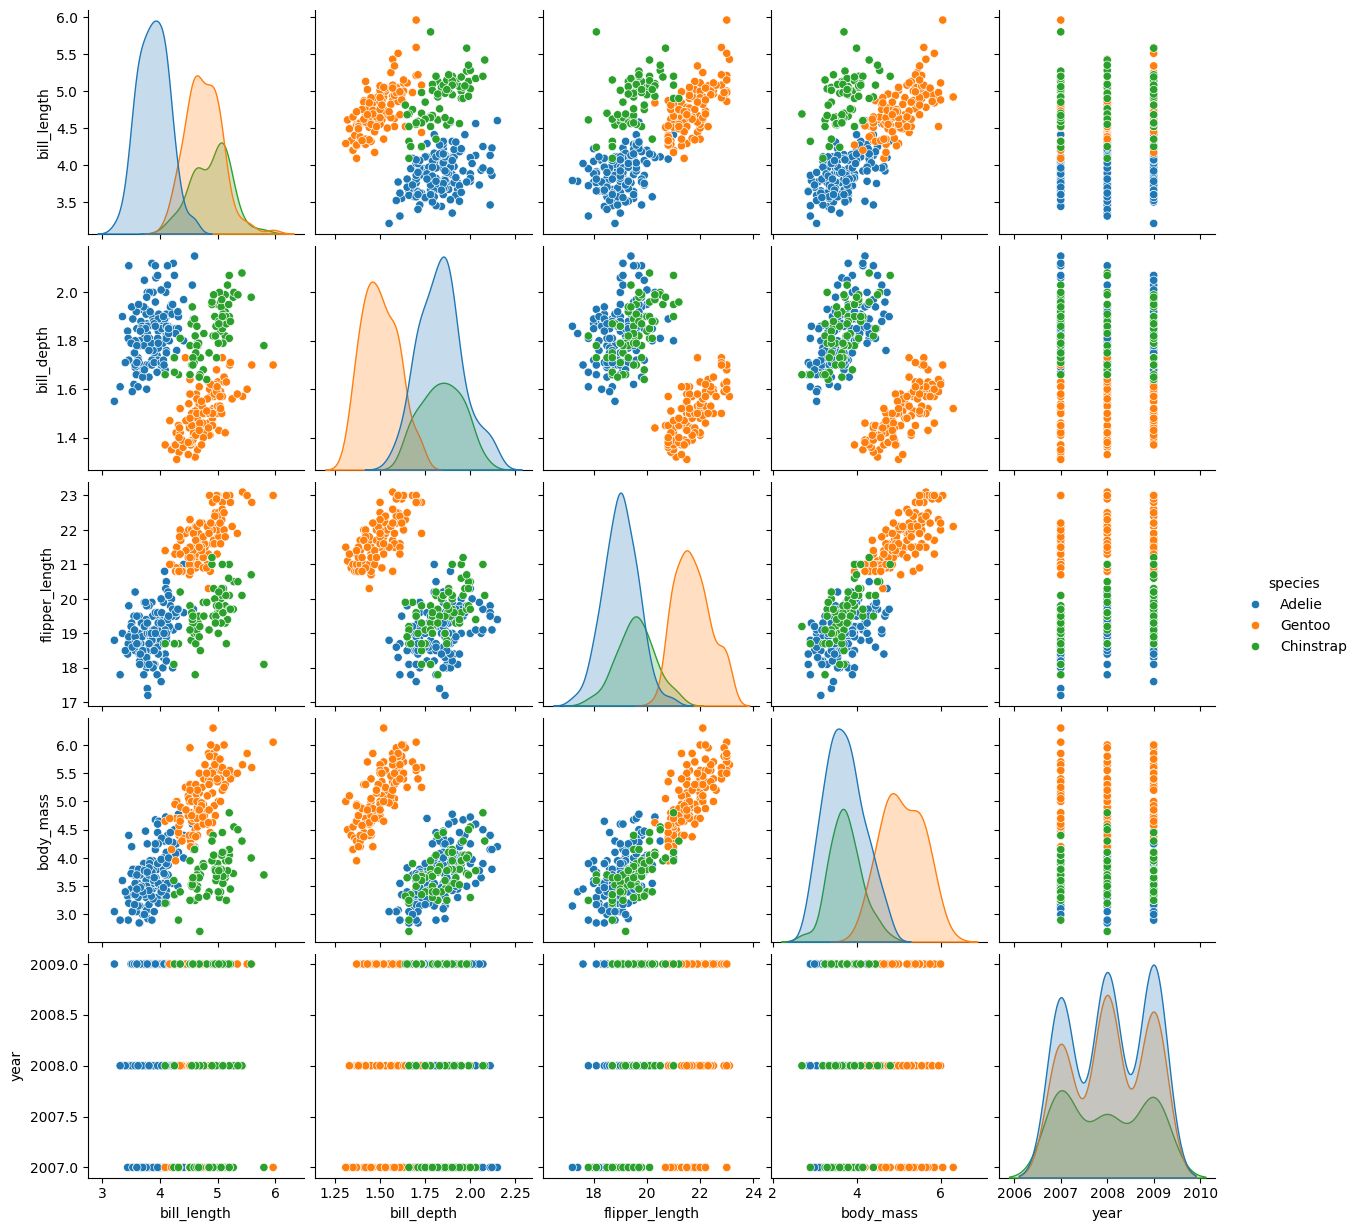

In [5]:
sns.pairplot(penguins, hue="species")

In [6]:
#flipper length, bill depth, bill length to predict mass

In [36]:
X = penguins[["flipper_length","bill_depth","bill_length"]].to_numpy().reshape(-1,3)
Y = penguins["body_mass"].to_numpy()

In [8]:
with pm.Model() as model_penguins:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, Y, m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_penguins = pm.sample(compute_convergence_checks=False)

Output()

In [9]:
pm.sample_posterior_predictive(idata_penguins, model_penguins,extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

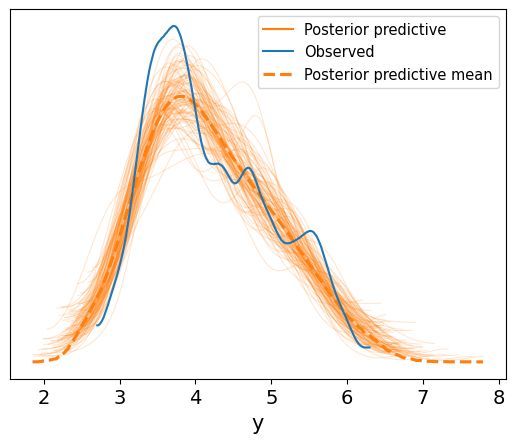

In [10]:
ax = az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])


In [11]:
with pm.Model() as model_penguins_log:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_penguins_log = pm.sample(compute_convergence_checks=False)

Output()

In [12]:
pm.sample_posterior_predictive(idata_penguins_log, model_penguins_log,extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='y'>

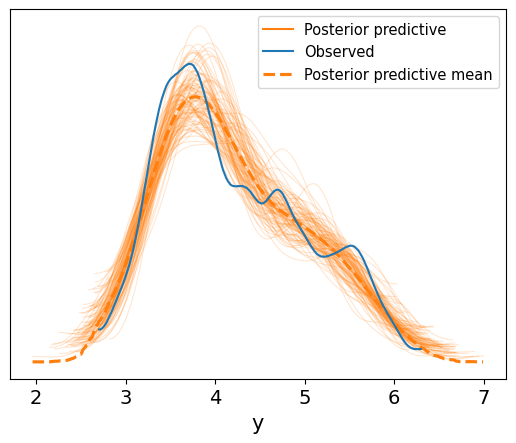

In [17]:
az.plot_ppc(idata_penguins_log, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [37]:
with pm.Model() as model_penguins_n:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_penguins_n = pm.sample(compute_convergence_checks=False)

Output()

In [38]:
pm.sample_posterior_predictive(idata_penguins_n, model_penguins_n, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

<Axes: xlabel='y'>

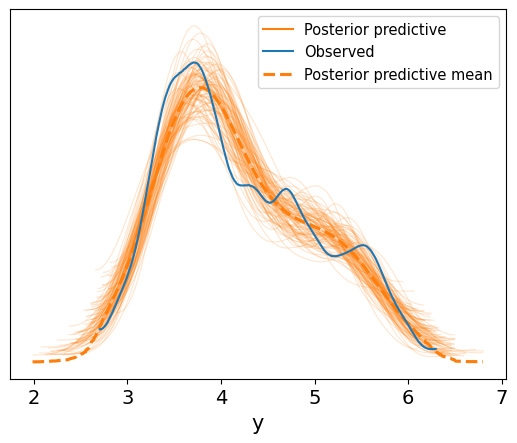

In [39]:
az.plot_ppc(idata_penguins_n, num_pp_samples=100, colors=["C1","C0","C1"])

It seems the normal models it best, so I'll use that one going forward

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [45]:
posterior_mean = idata_penguins_n.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguins_n, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins_n, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


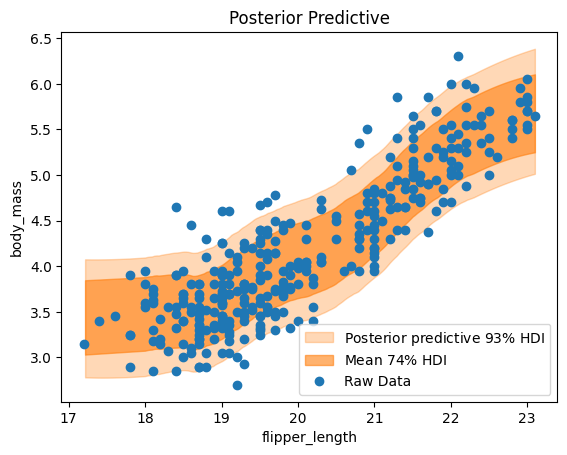

In [55]:
#genimi
idx = np.argsort(X[:, 0]) # grab the first column (flipper_length)
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[idx, 0],
    y=pps[:,idx],
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X[idx, 0],
    y=pps[:,idx],
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(X[idx, 0], Y[idx], "o", c="C0", label="Raw Data") # Use the sorted X and Y data
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

- It models the overall trend well, though it seems to model a narrower range than what the data suggests. I think it's leaving out some other factors that may be influencing how flipper length influences body mass. For example, I can see two distinct clusters (which may actually be 3 species, not making that mistake again) in the graph that aren't modeled, and suggest an external variable affecting their relationship.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

AttributeError: 'numpy.ndarray' object has no attribute 'xlabel'

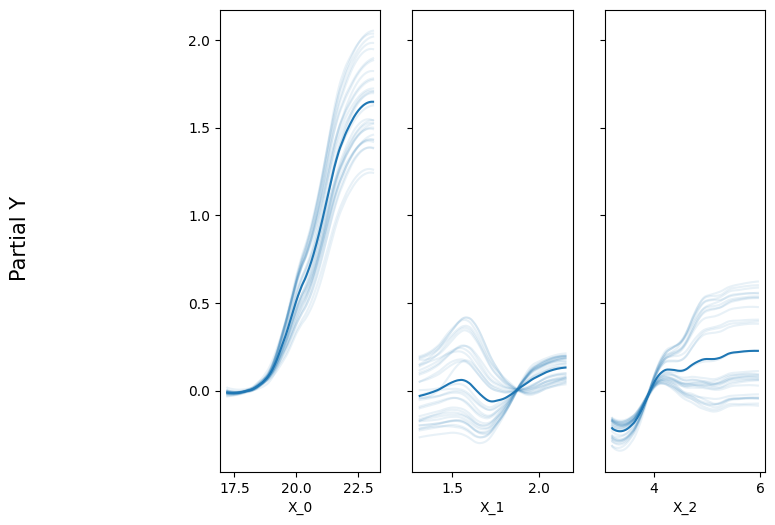

In [59]:
ax = pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))
# x axis graphs: "flipper_length","bill_depth","bill_length"

In [56]:
vi_penguins = pmb.compute_variable_importance(idata_penguins_n, μ_, X)

<Axes: ylabel='R²'>

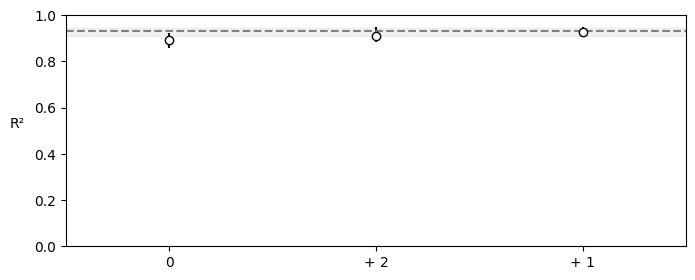

In [57]:
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

- From the vi, it looks like they're all very important, with R^2 correlations of above .8.
- Each variable seems to have a positive correlation to body mass, barring bill depth. Flipper length is by far the strongest positive correlation and the least variable. At higher flipper lengths, it seems to vary more.
- Bill depth has an inflection point, which indicates an interaction with another variable. It also has a lot of variance, to the point where we can't say theres a significant positive correlation to body mass.
- Bill length has a strong positive correlation in the first third (about), but then plateaus and varies widely.